In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

state schema

In [2]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    operation: str
    result: str

node 

In [ ]:
def perform_operation(state: AgentState) -> AgentState:
    """To perform the operation based on the user's input."""
    if state["operation"] == "+":
        state["result"] = "Hi " + state["name"] + ", your answer is: " + str(sum(state["values"]))
    elif state["operation"] == "*":
        product = 1
        for value in state["values"]:
            product *= value
        state["result"] = "Hi " + state["name"] + ", your answer is: " + str(product)
    else:
        state["result"] = "Hi " + state["name"] + ", you did not provide a valid operation. Please use '+' or '*'."
    
    return state

graph structure

In [5]:
graph = StateGraph(AgentState)
graph.add_node("perform_operation_node", perform_operation)   # name, action/function
graph.set_entry_point("perform_operation_node")
graph.set_finish_point("perform_operation_node")
app = graph.compile()

visualize

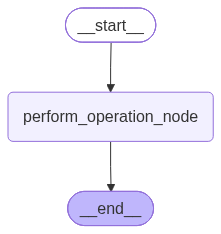

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # display the graph as an image in the notebook

invoke graph

In [18]:
ans = app.invoke({"values": [2,2,3], "name": "rhea", "operation": "+"})

In [19]:
ans

{'values': [2, 2, 3],
 'name': 'rhea',
 'operation': '+',
 'result': 'Hi rhea, your answer is: 7'}

In [20]:
ans["result"]  # print the final state after the graph execution

'Hi rhea, your answer is: 7'